In [2]:
# Import statements
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Special imports
import mlqmcpy as mp
from mlqmcpy.problems.elliptic import solve_elliptic_pde, elliptic

In [1]:
import qmcpy as qp 

In [9]:
# OPTIONS
num_levels = 3
cost_per_level = [
    2 ** (level - num_levels + 1) for level in range(num_levels)
]  # Rescale so that finest level has unit cost
initial_sample_size = 4
# error_tolerance = 1e-3
max_budget = 500
if False:
    iterator = mp.GreedyMLQMCIterator(
        8,
        initial_sample_size=initial_sample_size,
        cost_per_level=cost_per_level,
        max_budget=max_budget,
        replications=10,
    )
elif False:
    iterator = mp.GreedyGaussianProcessMLQMCIterator(
        8,
        initial_sample_size=initial_sample_size,
        cost_per_level=cost_per_level,
        max_budget=max_budget,
        discrete_distribution_type = qp.DigitalNetB2,
        kwargs_fastgp_construct = {},
        kwargs_fastgp_fit = {"verbose":0},
    )
elif False:
    iterator = mp.MultiTaskGaussianProcessMLQMCIteratorFunction(
        8,
        initial_sample_size=initial_sample_size,
        cost_per_level=cost_per_level,
        max_budget=max_budget,
        discrete_distribution_type = qp.DigitalNetB2,
        kwargs_fastgp_construct = {},
        kwargs_fastgp_fit = {"verbose":0},
    )
elif True:
    iterator = mp.MultiTaskGaussianProcessMLQMCIteratorDifference(
        8,
        initial_sample_size=initial_sample_size,
        cost_per_level=cost_per_level,
        max_budget=max_budget,
        discrete_distribution_type = qp.DigitalNetB2,
        kwargs_fastgp_construct = {},
        kwargs_fastgp_fit = {"verbose":0},
    )
else:
    assert False, "please select an iterator by switching a case to True"

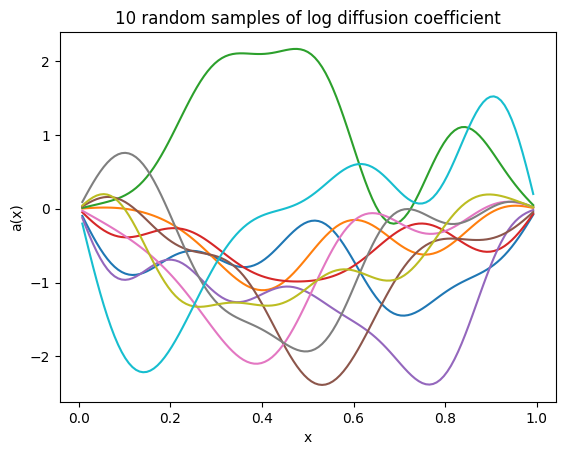

In [10]:
# Plot coefficients
_, ax = plt.subplots()
for _ in range(10):
    _, x, a_x, _ = solve_elliptic_pde()
    ax.plot(x, np.log(a_x))
ax.set_xlabel("x")
ax.set_ylabel("a(x)")
ax.set_title("10 random samples of log diffusion coefficient")
plt.show()

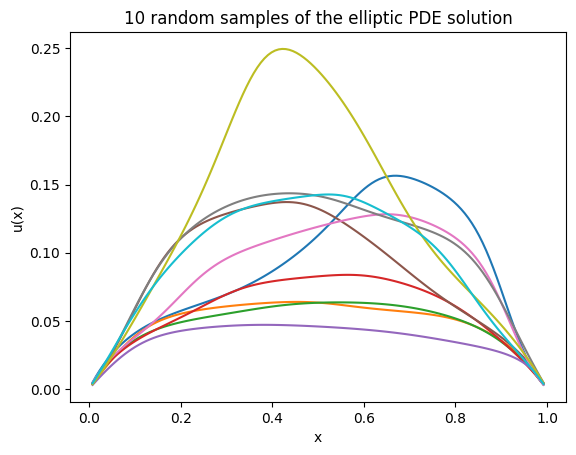

In [11]:
# Plot solutions
_, ax = plt.subplots()
for _ in range(10):
    _, x, _, u = solve_elliptic_pde()
    ax.plot(x, u)
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("10 random samples of the elliptic PDE solution")
plt.show()

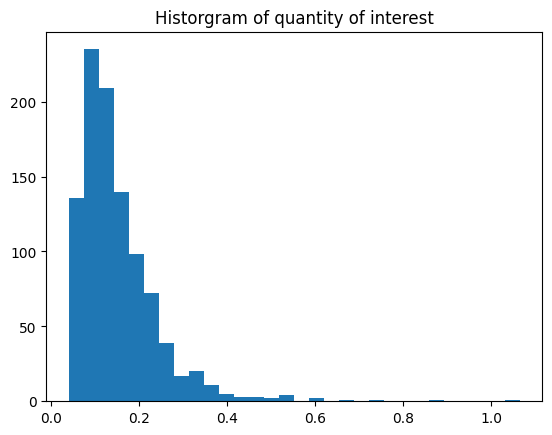

In [12]:
# Plot histogram
_, ax = plt.subplots()
u_samples = [solve_elliptic_pde(4)[0] for _ in range(1000)]
ax.hist(u_samples, bins=30)
ax.set_title("Historgram of quantity of interest")
plt.show()

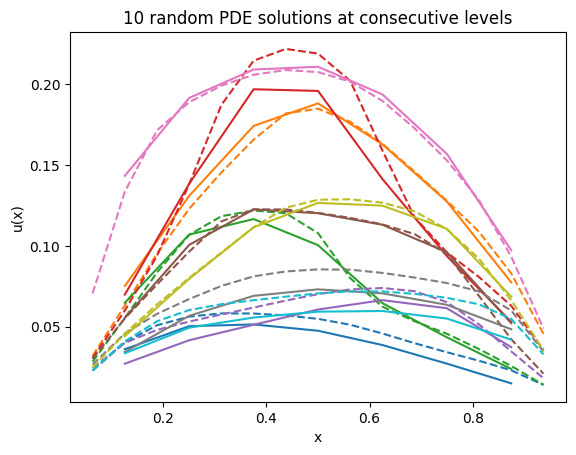

In [13]:
# Check correlations
_, ax = plt.subplots()
for j in range(10):
    coeffs = np.random.rand(8)
    _, x, _, u = solve_elliptic_pde(1, coeffs)
    ax.plot(x, u, color=f"C{j}")
    _, x, _, u = solve_elliptic_pde(2, coeffs)
    ax.plot(x, u, color=f"C{j}", linestyle="dashed")
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("10 random PDE solutions at consecutive levels")
plt.show()

In [14]:
# Iterate over the sampler
problem = elliptic.ml if not isinstance(iterator,mp.MultiTaskGaussianProcessMLQMCIteratorFunction) else elliptic

for iter, new_samples in enumerate(iterator):

    print(f"\nIteration {iter}\n")

    # Solve the PDE
    new_results = {
        level: np.array([problem(level, sample) for sample in samples])
        for level, samples in new_samples.items()
    }

    # Update the sampler with computed outputs
    iterator.update(new_results)

    # Print status
    iterator.print_status()
    print(
        f"Current error: {iterator.standard_error:.3e}, current cost: {int(iterator.cost)}"
    )


Iteration 0

	 number of samples: [4 4 4]
	              mean: 0.1453308088308988
	    standard error: 0.08521149296932251
Current error: 8.521e-02, current cost: 7

Iteration 1

	 number of samples: [16  4  4]
	              mean: 0.13292784231384677
	    standard error: 0.04051914218129298
Current error: 4.052e-02, current cost: 10

Iteration 2

	 number of samples: [32  4  4]
	              mean: 0.19018496798137596
	    standard error: 0.02444976198467983
Current error: 2.445e-02, current cost: 14

Iteration 3

	 number of samples: [64  4  4]
	              mean: 0.17827904150845308
	    standard error: 0.01996592850127923
Current error: 1.997e-02, current cost: 22

Iteration 4

	 number of samples: [128   4   4]
	              mean: 0.17386902068607635
	    standard error: 0.013995806606259802
Current error: 1.400e-02, current cost: 38

Iteration 5

	 number of samples: [128  64   4]
	              mean: 0.14565429097174357
	    standard error: 0.012881645632505531
Current error: